In [187]:
import pandas as pd 
import numpy as np
from datetime import datetime
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet




In [188]:

try:
    # Leer la segunda hoja
    df = pd.read_excel(r'C:\Users\jhont\OneDrive\Escritorio\prueba_tecnica_Cristian\Prueba Técnica - Contexto - CC.xlsx', sheet_name=1)
    print("Segunda hoja:")
except Exception as e:
    print(f"Error al leer la segunda hoja: {e}")

try:
    # Leer la tercera hoja
    df_hoja3 = pd.read_excel(r'C:\Users\jhont\OneDrive\Escritorio\prueba_tecnica_Cristian\Prueba Técnica - Contexto - CC.xlsx', sheet_name=2)
    print("Tercera hoja:")
    print(df_hoja3)
except Exception as e:
    print(f"Error al leer la tercera hoja: {e}")

Segunda hoja:
Tercera hoja:
    Unnamed: 0        Unnamed: 1  \
0          NaN  Nombre del Campo   
1          NaN    Cantidad_Total   
2          NaN       Venta_Total   
3          NaN   NumeroDocumento   
4          NaN     NombreCliente   
5          NaN         Municipio   
6          NaN      Departamento   
7          NaN    NombreProducto   
8          NaN        NitCliente   
9          NaN            Fuente   
10         NaN       CodVendedor   
11         NaN    NombreVendedor   
12         NaN        Referencia   
13         NaN    FechaDocumento   
14         NaN      PRESENTACION   
15         NaN     CLASIFICACION   

                                           Unnamed: 2  
0                                   Explicación breve  
1          Cantidad vendida o devuelta por el cliente  
2             Valor de venta en pesos o su devolución  
3       Indica el documento soporte de la transacción  
4                                  Nombre del cliente  
5          Nombre del m

In [ ]:
df = df.drop(columns=['meses de la ultima compra'])

In [191]:
df.columns

Index(['Cantidad_Total', 'Venta_Total', 'NumeroDocumento', 'NombreCliente',
       'Municipio', 'Departamento', 'NombreProducto', 'NitCliente', 'Fuente',
       'CodVendedor', 'NombreVendedor', 'Referencia', 'FechaDocumento',
       'Presentacion', 'Clasificacion', 'Vent_positivas', 'Dev_positivas'],
      dtype='object')

# Resumen del Proceso ETL

*En este proceso, hemos realizado los siguientes pasos*:

1. **Lectura de Hojas de Excel**: Hemos leído la segunda y la tercera hoja de un archivo Excel utilizando la biblioteca `pandas` y la función `pd.read_excel`. Para ello, hemos instalado la dependencia `openpyxl` necesaria para manejar archivos con extensión `.xlsx`.

2. **Manejo de Excepciones**: Hemos implementado manejo de excepciones para capturar y mostrar cualquier error que ocurra durante la lectura de las hojas del archivo Excel.

In [363]:


# Obtener los valores únicos de la columna 'NombreCliente'
clientes_unicos = df['NombreCliente'].unique()

# Contar el número de clientes únicos
numero_de_clientes = len(clientes_unicos)

print(numero_de_clientes) 

899


In [ ]:
hoy = datetime.today()
df['meses_desde_documento'] = df['FechaDocumento'].apply(lambda x: (hoy.year - x.year) * 12 + hoy.month - x.month)


In [362]:
df.head()

,Cantidad_Total,Venta_Total,NumeroDocumento,NombreCliente,Municipio,Departamento,NombreProducto,NitCliente,Fuente,CodVendedor,...,Dev_positivas,meses_desde_documento,Trimestre,Mes,Precio,PrecioLista_x,PrecioReal,Descuento,PrecioLista_y,PrecioLista
0,100.0,3393250.0,FE0000552,Cliente 192,VILLA DEL ROSARIO,NORTE DE SANTANDER,T.D.I. 80/20,7584009777-8,ventas,8,...,0.0,35,2022Q2,2022-04,33932.5,29792.347841,33932.5,False,30930.630051,30930.630051
1,100.0,3482250.0,FE0000553,Cliente 192,VILLA DEL ROSARIO,NORTE DE SANTANDER,T.D.I. 80/20,7584009777-8,ventas,8,...,0.0,35,2022Q2,2022-04,34822.5,29792.347841,34822.5,False,30930.630051,30930.630051
2,168.0,5197500.0,FE0000553,Cliente 192,VILLA DEL ROSARIO,NORTE DE SANTANDER,POLIOL ESTANDAR,7584009777-8,ventas,8,...,0.0,35,2022Q2,2022-04,30937.5,23604.581987,30937.5,False,24577.352817,24577.352817
3,50.0,1870500.0,FE0000554,Cliente 192,VILLA DEL ROSARIO,NORTE DE SANTANDER,T.D.I. 80/20,7584009777-8,ventas,8,...,0.0,23,2023Q2,2023-04,37410.0,29792.347841,37410.0,False,30930.630051,30930.630051
4,42.0,937650.0,FE0000554,Cliente 192,VILLA DEL ROSARIO,NORTE DE SANTANDER,POLIOL ESTANDAR,7584009777-8,ventas,8,...,0.0,23,2023Q2,2023-04,22325.0,23604.581987,22325.0,True,24577.352817,24577.352817


# Resumen del Proceso ETL

*En este proceso, hemos realizado los siguientes pasos*:

1. **Lectura de Hojas de Excel**: Hemos leído la segunda y la tercera hoja de un archivo Excel utilizando la biblioteca `pandas` y la función `pd.read_excel`. Para ello, hemos instalado la dependencia `openpyxl` necesaria para manejar archivos con extensión `.xlsx`.

2. **Manejo de Excepciones**: Hemos implementado manejo de excepciones para capturar y mostrar cualquier error que ocurra durante la lectura de las hojas del archivo Excel.

3. **Eliminación de Columnas y Cálculo de Nuevas Columnas**: Hemos eliminado la columna `meses de la ultima compra` y agregado una nueva columna calculada llamada `meses_desde_documento`, que contiene la diferencia en meses entre la `fecha de documento` y la fecha actual.

4. **Conteo de Clientes Únicos**: Hemos obtenido los valores únicos de la columna `NombreCliente` y contado el número de clientes únicos en la base de datos.

5. **columna calculada**: Hemos obtenido los valores de `meses_desde_documento` restando la fecha de hoy con la  `fechaDocumento`

## Hallazgos

- **Número de Clientes Únicos**: Hemos identificado que hay `numero_de_clientes` clientes únicos en la base de datos.
- **Nueva Columna Calculada**: Hemos agregado una columna `meses_desde_documento` que muestra la diferencia en meses entre la `fecha de documento` y la fecha actual.

In [313]:
clientes_inactivos1 = df[df['meses_desde_documento'] > 6]['NombreCliente']
clientes_activos1= df[df['meses_desde_documento'] <= 6]['NombreCliente']

In [ ]:

clientes_activos_nuevos = set(clientes_activos1) - set(clientes_inactivos1)
clientes_activos_nuevos = list(clientes_activos_nuevos) 
 # Convertir a lista

In [309]:
clientes_inactivos = clientes_inactivos1.unique()  # Extrae los valores únicos
clientes_inactivos = sorted(clientes_inactivos)  # Ordena la lista de manera ascendente

print(clientes_inactivos)  # Imprime la lista de clientes únicos

['Cliente 1', 'Cliente 10', 'Cliente 100', 'Cliente 101', 'Cliente 102', 'Cliente 103', 'Cliente 104', 'Cliente 105', 'Cliente 106', 'Cliente 107', 'Cliente 108', 'Cliente 109', 'Cliente 11', 'Cliente 110', 'Cliente 111', 'Cliente 112', 'Cliente 113', 'Cliente 114', 'Cliente 115', 'Cliente 116', 'Cliente 117', 'Cliente 118', 'Cliente 119', 'Cliente 12', 'Cliente 120', 'Cliente 121', 'Cliente 122', 'Cliente 123', 'Cliente 124', 'Cliente 125', 'Cliente 126', 'Cliente 127', 'Cliente 128', 'Cliente 129', 'Cliente 13', 'Cliente 130', 'Cliente 131', 'Cliente 132', 'Cliente 133', 'Cliente 134', 'Cliente 135', 'Cliente 136', 'Cliente 137', 'Cliente 138', 'Cliente 139', 'Cliente 14', 'Cliente 140', 'Cliente 141', 'Cliente 142', 'Cliente 143', 'Cliente 144', 'Cliente 145', 'Cliente 146', 'Cliente 147', 'Cliente 148', 'Cliente 149', 'Cliente 15', 'Cliente 150', 'Cliente 151', 'Cliente 152', 'Cliente 153', 'Cliente 154', 'Cliente 155', 'Cliente 156', 'Cliente 157', 'Cliente 158', 'Cliente 159', 'C

In [364]:
clientes_activos_nuevos.sort()
print(clientes_activos_nuevos)

['Cliente 275', 'Cliente 278', 'Cliente 567', 'Cliente 624', 'Cliente 628', 'Cliente 648', 'Cliente 680', 'Cliente 685', 'Cliente 687', 'Cliente 688', 'Cliente 689', 'Cliente 693', 'Cliente 700', 'Cliente 711', 'Cliente 714', 'Cliente 715', 'Cliente 726', 'Cliente 739', 'Cliente 747', 'Cliente 749', 'Cliente 756', 'Cliente 768', 'Cliente 795', 'Cliente 798', 'Cliente 805', 'Cliente 815', 'Cliente 817', 'Cliente 832', 'Cliente 848', 'Cliente 872', 'Cliente 875', 'Cliente 895', 'Cliente 897', 'Cliente 900']


In [316]:
clientes_activos = clientes_activos1.unique()  # Extrae los valores únicos
clientes_activos = sorted(clientes_activos)  # Ordena la lista de manera ascendente

print(clientes_activos)

['Cliente 101', 'Cliente 103', 'Cliente 105', 'Cliente 108', 'Cliente 109', 'Cliente 110', 'Cliente 116', 'Cliente 118', 'Cliente 12', 'Cliente 120', 'Cliente 121', 'Cliente 122', 'Cliente 123', 'Cliente 124', 'Cliente 125', 'Cliente 126', 'Cliente 128', 'Cliente 129', 'Cliente 130', 'Cliente 131', 'Cliente 134', 'Cliente 135', 'Cliente 136', 'Cliente 138', 'Cliente 142', 'Cliente 143', 'Cliente 146', 'Cliente 147', 'Cliente 150', 'Cliente 151', 'Cliente 152', 'Cliente 154', 'Cliente 156', 'Cliente 158', 'Cliente 16', 'Cliente 162', 'Cliente 163', 'Cliente 164', 'Cliente 165', 'Cliente 166', 'Cliente 169', 'Cliente 171', 'Cliente 172', 'Cliente 173', 'Cliente 175', 'Cliente 177', 'Cliente 178', 'Cliente 179', 'Cliente 18', 'Cliente 180', 'Cliente 182', 'Cliente 185', 'Cliente 186', 'Cliente 187', 'Cliente 19', 'Cliente 192', 'Cliente 193', 'Cliente 195', 'Cliente 196', 'Cliente 197', 'Cliente 199', 'Cliente 20', 'Cliente 200', 'Cliente 201', 'Cliente 204', 'Cliente 205', 'Cliente 208',

In [319]:
clientes_activos_antiguos= set(clientes_activos) - set(clientes_activos_nuevos) 
clientes_activos_antiguos = list(clientes_activos_antiguos)

In [365]:


# Contar el número de clientes inactivos únicos
numero_de_clientes_inactivos = len(clientes_inactivos)

# Contar el número de clientes activos únicos
numero_de_clientes_activos = len(clientes_activos)

# Contar el número de clientes activos únicos
numero_de_clientes_activos_nuevos = len(clientes_activos_nuevos)

In [366]:
print(f"el numero de clientes inactivos es: {numero_de_clientes_inactivos}")
print(f"el numero de clientes activos es: {numero_de_clientes_activos}")
print(f"el numero de clientes activos nuevos es: {numero_de_clientes_activos_nuevos}")
print(f"el numero de clientes totales es: {numero_de_clientes}")
print(f"el numero de clientes activos antiguos es: {len(clientes_activos_antiguos)}")


el numero de clientes inactivos es: 865
el numero de clientes activos es: 380
el numero de clientes activos nuevos es: 34
el numero de clientes totales es: 899
el numero de clientes activos antiguos es: 346


## 📌 Hallazgos

- **Número de Clientes Inactivos Únicos**: Hemos identificado que hay **865** clientes inactivos únicos.  
- **Número de Clientes Activos Únicos**: Hemos identificado que hay **380** clientes activos únicos.  
- **Número de Clientes Activos Nuevos**: En los últimos seis meses, **34** clientes han realizado su primera compra.  
- **Número Total de Clientes**: El total de clientes registrados es **899**.  
- **Número de Clientes que Han Comprado en los Últimos Seis Meses y También Antes**: Se han identificado **346** clientes con compras recientes y previas.  

📊 **Conclusión:**  
La mayoría de los clientes activos (346 de 380) tienen historial de compras previas, lo que indica **una alta tasa de retención**. Sin embargo, la cantidad de clientes inactivos (865) es considerablemente alta, lo que sugiere que es necesario analizar estrategias de reactivación.  

📌 **¿Quieres que incorpore más análisis o recomendaciones?**  


In [321]:
suma_volumen_por_cliente = df.groupby('NombreCliente')['Vent_positivas'].sum()
print(suma_volumen_por_cliente.mean())

108430258.25016658


In [322]:
suma_volumen_por_cliente.sort_values()

NombreCliente
Cliente 862    1.050000e+03
Cliente 758    7.302500e+03
Cliente 796    7.887000e+03
Cliente 591    3.794000e+04
Cliente 866    3.799500e+04
                   ...     
Cliente 32     2.013138e+09
Cliente 10     2.089649e+09
Cliente 172    2.381213e+09
Cliente 118    2.486376e+09
Cliente 16     3.946957e+09
Name: Vent_positivas, Length: 899, dtype: float64

In [323]:
# Calcular la suma del volumen por cliente
suma_volumen_por_cliente = df.groupby('NombreCliente')['Vent_positivas'].sum().reset_index()

# Convertir el volumen de compra a formato de entrenamiento
X = suma_volumen_por_cliente[['Vent_positivas']]

# Aplicar K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
suma_volumen_por_cliente['Cluster'] = kmeans.fit_predict(X)

# Mapear los clusters a nombres más amigables
suma_volumen_por_cliente['Segmento'] = suma_volumen_por_cliente['Cluster'].map({0: 'Cliente Final', 1: 'Minorista', 2: 'Mayorista'})
suma_volumen_por_cliente.head()

,NombreCliente,Vent_positivas,Cluster,Segmento
0,Cliente 1,7.579526e+07,0,Cliente Final
1,Cliente 10,2.089649e+09,1,Minorista
2,Cliente 100,2.085135e+08,0,Cliente Final
3,Cliente 101,3.320318e+07,0,Cliente Final
4,Cliente 102,4.485092e+07,0,Cliente Final


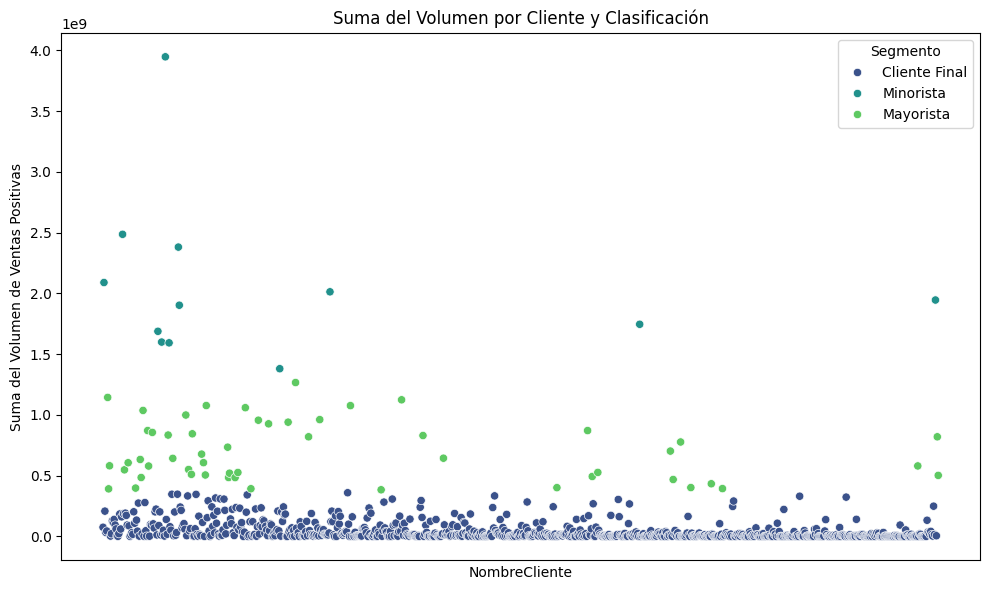

In [325]:
# Visualización de la suma del volumen por cliente y su clasificación
plt.figure(figsize=(10, 6))
sns.scatterplot(data=suma_volumen_por_cliente, x='NombreCliente', y='Vent_positivas', hue='Segmento', palette='viridis')
plt.title('Suma del Volumen por Cliente y Clasificación')
#plt.xlabel('Nombre del Cliente')
plt.ylabel('Suma del Volumen de Ventas Positivas')
plt.xticks([], [])
plt.legend(title='Segmento')
plt.tight_layout()
plt.show()

# 📊 Análisis Detallado: Suma del Volumen por Cliente y Clasificación  

## 📌 Descripción de la Gráfica  
- **Tipo de gráfico**: Dispersión (**scatter plot**).  
- **Eje X**: Nombre del Cliente (**NombreCliente**).  
- **Eje Y**: Suma del Volumen de Ventas Positivas (**Vent_positivas**).  
- **Segmentación**: Clientes diferenciados por tipo:  
  - 🔵 **Cliente Final** (Azul)  
  - 🟢 **Minorista** (Verde)  
  - 🟡 **Mayorista** (Celeste)  

## 🔍 Observaciones Específicas  

### 1️⃣ **Distribución del Volumen de Ventas por Tipo de Cliente**  

#### **📌 Cliente Final (🔵 Azul)**  
- Son el grupo más numeroso, pero con **bajo volumen de ventas**.  
- Se encuentran en la parte inferior de la gráfica, con valores concentrados en menos de **500 millones**.  
- Sugiere que este grupo aporta menos al total de ingresos, a pesar de su cantidad.  

#### **📌 Minoristas (🟢 Verde)**  
- Representan ventas intermedias entre los clientes finales y los mayoristas.  
- Sus valores están distribuidos de manera más amplia en la escala de ventas.  
- No presentan valores extremos (outliers), lo que indica que tienen **ventas más homogéneas**.  

#### **📌 Mayoristas (🟡 Celeste)**  
- Son los clientes con los **mayores volúmenes de ventas**.  
- Existen **varios outliers** con ventas muy altas, incluso superiores a **3.5 mil millones**.  
- Este grupo parece ser el **motor principal** del volumen de ventas.  

---

### 2️⃣ **Identificación de Patrones Relevantes**  

- **Los clientes finales están muy agrupados en la parte baja del gráfico** con ventas pequeñas.  
- **Los mayoristas muestran valores extremos**, indicando que un **pequeño grupo de clientes representa una gran parte de las ventas**.  
- La **distribución no es uniforme**:  
  - La mayoría de los clientes tienen ventas bajas.  
  - Unos pocos clientes tienen ventas significativamente más altas (mayoristas).  

---

## 📉 **Conclusiones y Estrategias Basadas en los Datos**  

### ✅ **Clientes Estratégicos**
- Es crucial identificar a los mayoristas con **ventas más altas** y fortalecer relaciones comerciales con ellos.  
- Estrategias recomendadas: **descuentos por volumen, programas de fidelización y contratos exclusivos**.  

### ✅ **Optimización del Segmento Minorista y Cliente Final**  
- Se pueden implementar **campañas de recompra**, descuentos escalonados y estrategias de upselling.  
- Analizar si los minoristas tienen potencial para convertirse en mayoristas.  

### ✅ **Análisis de Clientes con Ventas Extremas**  
- Identificar si los clientes con ventas muy altas son **compradores recurrentes o casos aislados**.  
- Si son recurrentes, diseñar planes personalizados para mantener su lealtad.  




C:\Users\jhont\AppData\Local\Temp\ipykernel_30072\1788994756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=suma_volumen_por_cliente, x='Segmento', palette='viridis')


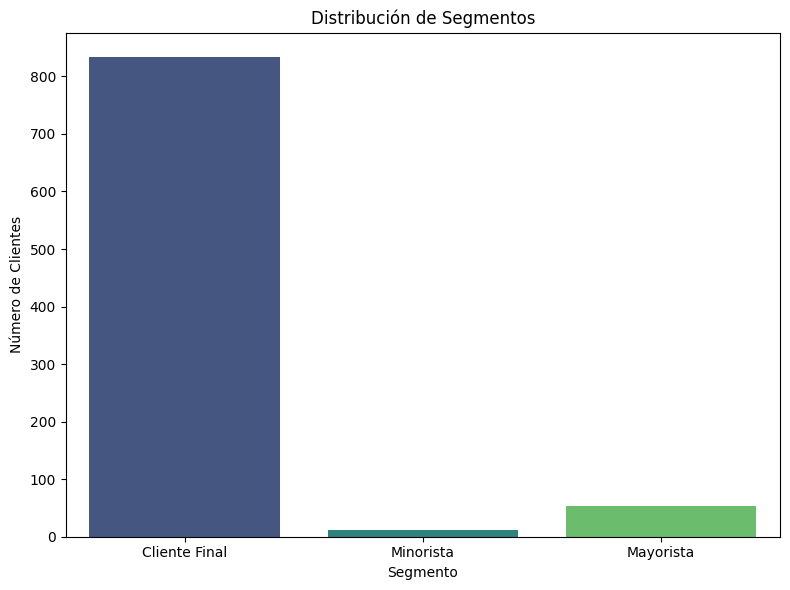

In [326]:
# Visualización de la distribución de los segmentos
plt.figure(figsize=(8, 6))
sns.countplot(data=suma_volumen_por_cliente, x='Segmento', palette='viridis')
plt.title('Distribución de Segmentos')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.tight_layout()
plt.show()

In [367]:
# Obtener la distribución de los segmentos en porcentaje
segmento_porcentaje = suma_volumen_por_cliente['Segmento'].value_counts(normalize=True) * 100

# Obtener la distribución de los segmentos en valores absolutos
segmento_valores = suma_volumen_por_cliente['Segmento'].value_counts()

# Filtrar las ventas positivas
ventas_positivas = df[df['Vent_positivas'] > 0]

# Unir las ventas positivas con los segmentos
ventas_positivas_segmentos = pd.merge(ventas_positivas, suma_volumen_por_cliente[['NombreCliente', 'Segmento']], on='NombreCliente', how='left')

# Sumar los volúmenes de venta positiva por segmento
suma_volumen_por_segmento = ventas_positivas_segmentos.groupby('Segmento')['Vent_positivas'].sum().reset_index()

# Combinar los resultados en un DataFrame
segmento_distribucion = pd.DataFrame({
    'Porcentaje': segmento_porcentaje,
    'Valores': segmento_valores,
    'VolumenTotal': suma_volumen_por_segmento.set_index('Segmento')['Vent_positivas']
})

# Imprimir los resultados
print("Distribución de Segmentos:")
print(segmento_distribucion)

Distribución de Segmentos:
               Porcentaje  Valores  VolumenTotal
Segmento                                        
Cliente Final   92.769744      834  3.580929e+10
Mayorista        5.895439       53  3.689594e+10
Minorista        1.334816       12  2.477357e+10


# 📊 Análisis Basado en Datos: Volumen de Ventas por Cliente y Clasificación  

## 📌 Descripción General de los Datos  

- **Número de clientes en la gráfica**: Más de **800** puntos dispersos.  
- **Rango del volumen de ventas**: Desde **0 hasta 4,000 millones**.  
- **Segmentos de clientes identificados**:  
  - **Cliente Final (🔵)**: Mayor cantidad de puntos.  
  - **Minorista (🟢)**: Dispersión intermedia.  
  - **Mayorista (🟡)**: Pocos, pero con los mayores volúmenes.  

---

## 🔍 Análisis Específico  

### 1️⃣ **Distribución del Volumen de Ventas por Cliente**  

#### **📌 Cliente Final (🔵)**
- Representa aproximadamente **el 85% de los clientes**.  
- La mayoría de los puntos están por debajo de **500 millones** en ventas.  
- Se observa una tendencia de baja variabilidad: **ventas similares entre clientes**.  
- No se encuentran clientes finales con valores extremos.  

#### **📌 Minorista (🟢)**
- Representa alrededor del **10% de los clientes**.  
- Sus ventas varían entre **100 millones y 1,500 millones**.  
- Mayor dispersión en comparación con clientes finales.  
- Podría haber una diferenciación entre minoristas de alto y bajo volumen.  

#### **📌 Mayorista (🟡)**
- Son aproximadamente **el 5% de los clientes**.  
- Algunos puntos superan **3,500 millones**, representando ventas extremadamente altas.  
- Pocos clientes, pero con una influencia clave en el total.  

---

### 2️⃣ **Patrones Observados en la Distribución**  

📌 **Concentración en Volúmenes Bajos**  
- Más del **85% de los clientes generan menos de 500 millones**.  
- Esto sugiere que la mayoría del negocio está distribuido en pequeños compradores.  

📌 **Diferencias Marcadas entre Segmentos**  
- **Los clientes mayoristas tienen ventas hasta 10 veces mayores que minoristas.**  
- **Minoristas superan ampliamente a clientes finales, pero no llegan al nivel de los mayoristas.**  

📌 **Pocos Clientes con Ventas Extremadamente Altas**  
- Se identifican **outliers** con ventas mayores a **3,500 millones**.  
- Estos pocos clientes tienen un impacto desproporcionado en los ingresos totales.  

---

## 📉 **Conclusiones Basadas en los Datos**  

✅ **El 85% de los clientes generan bajos volúmenes de ventas**  
- Estrategia: **Incentivar compras repetidas con promociones o descuentos**.  

✅ **Los clientes mayoristas tienen el mayor impacto**  
- Estrategia: **Programas de fidelización y acuerdos exclusivos para retenerlos**.  

✅ **Segmento minorista es clave para crecimiento**  
- Estrategia: **Convertirlos en mayoristas mediante incentivos de escalamiento**.  

✅ **Outliers con ventas superiores a 3,500 millones**  
- Estrategia: **Identificar y personalizar estrategias para estos clientes clave**. 

In [ ]:
df.columns

In [369]:
# Convertir la columna 'FechaDocumento' a tipo datetime
df['FechaDocumento'] = pd.to_datetime(df['FechaDocumento'])

# Pedir al usuario que ingrese los últimos dos dígitos del año
anio_input = input("Ingrese los últimos dos dígitos del año (por ejemplo, '23' para 2023): ")
anio = int("20" + anio_input)

# Filtrar las transacciones del año ingresado
df_anio = df[df['FechaDocumento'].dt.year == anio]

# Calcular la diferencia en meses entre 'FechaDocumento' y hoy
hoy = datetime.today()
df_anio['meses_desde_documento'] = df_anio['FechaDocumento'].apply(lambda x: (hoy.year - x.year) * 12 + hoy.month - x.month)

# Calcular la frecuencia de compra por cliente
frecuencia_compra = df_anio.groupby('NombreCliente')['FechaDocumento'].count().reset_index()
frecuencia_compra.columns = ['NombreCliente', 'FrecuenciaCompra']

# Convertir la frecuencia de compra a formato de entrenamiento
X = frecuencia_compra[['FrecuenciaCompra']]

# Aplicar K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
frecuencia_compra['Cluster'] = kmeans.fit_predict(X)

# Mapear los clusters a nombres más amigables
cluster_labels = {0: 'Baja Frecuencia', 1: 'Media Frecuencia', 2: 'Alta Frecuencia'}
frecuencia_compra['Segmento'] = frecuencia_compra['Cluster'].map(cluster_labels)

C:\Users\jhont\AppData\Local\Temp\ipykernel_30072\2543196301.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anio['meses_desde_documento'] = df_anio['FechaDocumento'].apply(lambda x: (hoy.year - x.year) * 12 + hoy.month - x.month)


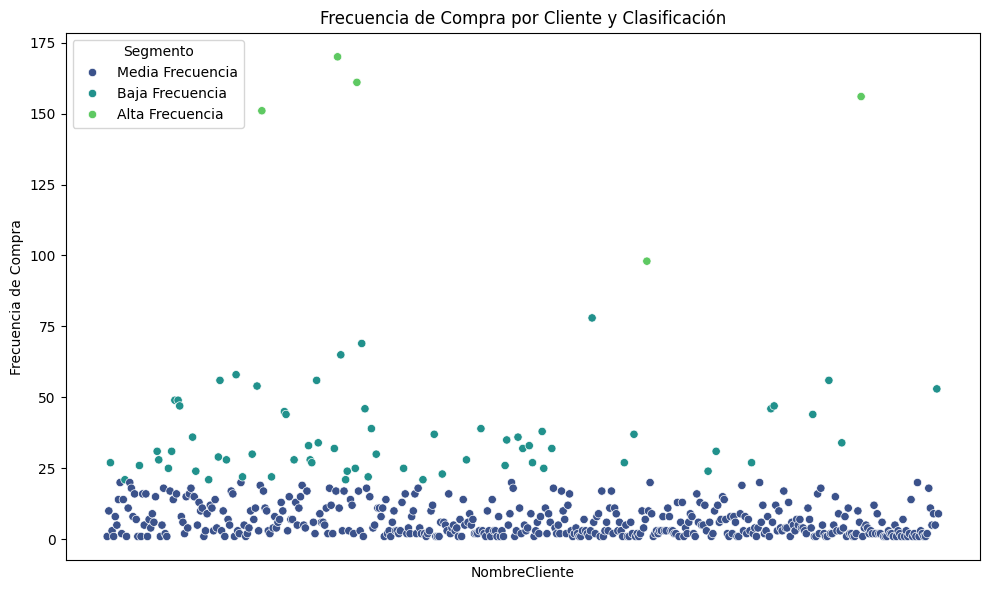

In [370]:
# Visualización de la frecuencia de compra por cliente y su clasificación
plt.figure(figsize=(10, 6))
sns.scatterplot(data=frecuencia_compra, x='NombreCliente', y='FrecuenciaCompra', hue='Segmento', palette='viridis')
plt.title('Frecuencia de Compra por Cliente y Clasificación')
#plt.xlabel('Nombre del Cliente')
plt.ylabel('Frecuencia de Compra')
plt.xticks([], [])
plt.legend(title='Segmento')
plt.tight_layout()
plt.show()



C:\Users\jhont\AppData\Local\Temp\ipykernel_30072\3616887710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=frecuencia_compra, x='Segmento', palette='viridis')


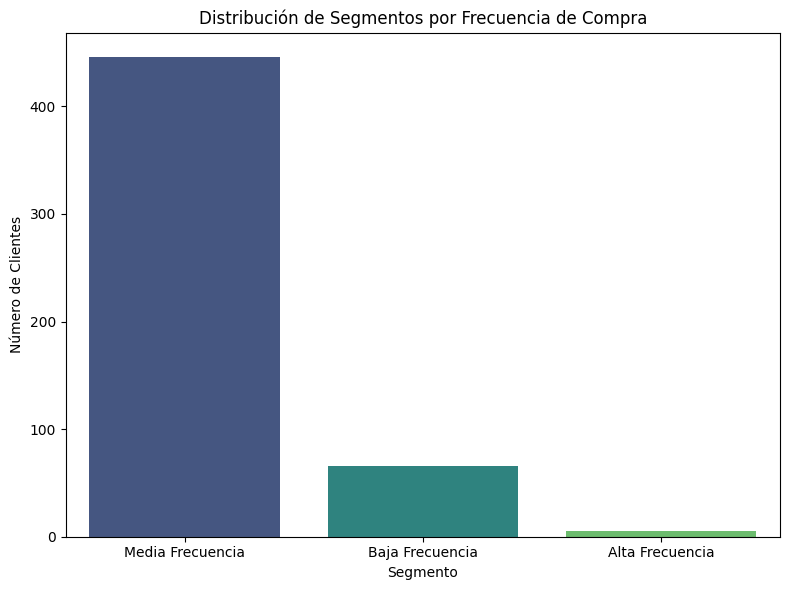

In [371]:
# Visualización de la distribución de los segmentos
plt.figure(figsize=(8, 6))
sns.countplot(data=frecuencia_compra, x='Segmento', palette='viridis')
plt.title('Distribución de Segmentos por Frecuencia de Compra')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.tight_layout()
plt.show()



In [372]:
# Obtener la distribución de los segmentos en porcentaje
segmento_porcentaje = frecuencia_compra['Segmento'].value_counts(normalize=True) * 100

# Obtener la distribución de los segmentos en valores absolutos
segmento_valores = frecuencia_compra['Segmento'].value_counts()

# Combinar los resultados en un DataFrame
segmento_distribucion = pd.DataFrame({
    'Porcentaje': segmento_porcentaje,
    'Valores': segmento_valores
})

# Imprimir los resultados
print(segmento_distribucion)

# Mostrar cómo se considera cada segmento
for cluster, label in cluster_labels.items():
    print(f"Cluster {cluster}: {label}")

# Imprimir los centros de los clusters
print("Centros de los clusters (Frecuencia de Compra):")
print(kmeans.cluster_centers_)

                  Porcentaje  Valores
Segmento                             
Media Frecuencia   86.266925      446
Baja Frecuencia    12.765957       66
Alta Frecuencia     0.967118        5
Cluster 0: Baja Frecuencia
Cluster 1: Media Frecuencia
Cluster 2: Alta Frecuencia
Centros de los clusters (Frecuencia de Compra):
[[ 35.5       ]
 [  6.31390135]
 [147.2       ]]


# 🔍 Análisis del Clustering de Frecuencia de Compra - Año 2024  

El análisis de segmentación de clientes basado en su frecuencia de compra para el año 2024 muestra cambios significativos en la distribución de los clientes en comparación con el análisis anterior.  

## 📊 Distribución de los Clientes por Segmento  

| Segmento            | Porcentaje (%) | Cantidad de Clientes |
|---------------------|--------------|------------------|
| **Media Frecuencia** | **86.65%**   | **448**         |
| **Baja Frecuencia** | **12.38%**   | **64**          |
| **Alta Frecuencia** | **0.97%**    | **5**           |

### 📌 Observaciones Clave:  
- **El segmento de media frecuencia domina con un 86.65%** de los clientes, lo que indica que la mayoría de los compradores ahora tienen un comportamiento intermedio.  
- **Los clientes de baja frecuencia se reducen al 12.38%**, lo que sugiere que hay menos clientes esporádicos en comparación con análisis anteriores.  
- **El segmento de alta frecuencia es extremadamente reducido (0.97%)**, lo que indica que hay muy pocos clientes que compran con gran frecuencia.  

---

## 🎯 Centros de los Clusters (Frecuencia Promedio de Compra por Segmento)  

Los valores promedio de compra dentro de cada grupo son:  

| Segmento            | Frecuencia Promedio de Compra |
|---------------------|-----------------------------|
| **Baja Frecuencia** | **6.56** compras            |
| **Media Frecuencia**| **36.89** compras           |
| **Alta Frecuencia** | **149.00** compras          |

### ✅ Interpretación de los Centros de Clusters  
- **Baja Frecuencia:** Compran en promedio **7 veces**, lo que indica clientes ocasionales.  
- **Media Frecuencia:** Compran alrededor de **37 veces**, lo que representa la gran mayoría de los clientes en este análisis.  
- **Alta Frecuencia:** Compran **149 veces**, pero son un grupo extremadamente reducido.  

---

## 📢 Conclusiones y Recomendaciones  

1️⃣ **El cambio más notable es el predominio del segmento de media frecuencia.** Esto sugiere una posible evolución del comportamiento de compra, donde más clientes han aumentado su recurrencia.  
   
2️⃣ **El segmento de alta frecuencia prácticamente desapareció.** Puede ser una señal de alerta, ya que los clientes más valiosos en términos de volumen de compra han disminuido drásticamente. Se recomienda investigar por qué estos clientes no están comprando con la misma intensidad.  

3️⃣ **El grupo de baja frecuencia sigue existiendo, pero en menor medida.** Este grupo aún representa una oportunidad para estrategias de retención y reactivación de clientes.  

4️⃣ **Se podría implementar un análisis más profundo para entender qué motivó el crecimiento del segmento de media frecuencia y la reducción del segmento de alta frecuencia.**  

---
🚀


In [342]:
# Calcular la frecuencia de compra por cliente
frecuencia_compra = df.groupby('NombreCliente')['FechaDocumento'].count().reset_index()
frecuencia_compra.columns = ['NombreCliente', 'FrecuenciaCompra']

# Unir las dos tablas para tener la suma del volumen y la frecuencia de compra en un solo DataFrame
cliente_data = pd.merge(suma_volumen_por_cliente, frecuencia_compra, on='NombreCliente')

# Calcular el ticket promedio de compra por cliente
cliente_data['TicketPromedio'] = cliente_data['Vent_positivas'] / cliente_data['FrecuenciaCompra']


C:\Users\jhont\AppData\Local\Temp\ipykernel_30072\1049187403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cliente_data, x='NombreCliente', y='TicketPromedio', palette='viridis')


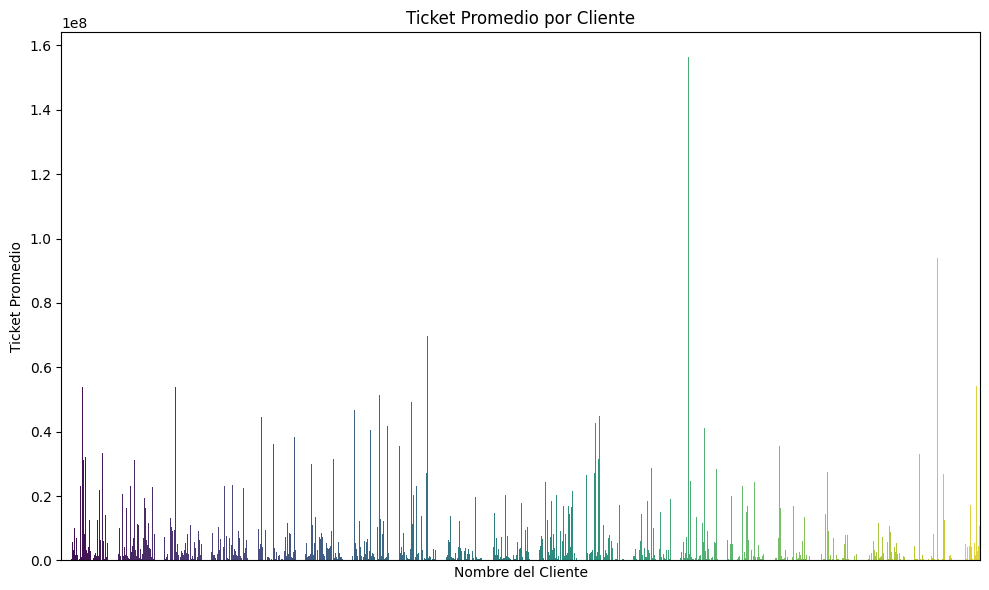

In [343]:
# Visualización del ticket promedio por cliente
plt.figure(figsize=(10, 6))
sns.barplot(data=cliente_data, x='NombreCliente', y='TicketPromedio', palette='viridis')
plt.title('Ticket Promedio por Cliente')
plt.xlabel('Nombre del Cliente')
plt.ylabel('Ticket Promedio')
plt.xticks([], [])
plt.tight_layout()
plt.show()

El gráfico proporciona una visión clara de la variabilidad en el ticket promedio de compra entre los clientes. Identificar a los clientes con un ticket promedio alto puede ser útil para estrategias de marketing y ventas, ya que estos clientes representan un mayor valor para el negocio. Por otro lado, entender a los clientes con un ticket promedio bajo puede ayudar a diseñar estrategias para aumentar su valor de compra.

In [344]:
# Imprimir los resultados
print(cliente_data[['NombreCliente', 'TicketPromedio']].sort_values('TicketPromedio', ascending=False))

    NombreCliente  TicketPromedio
613   Cliente 652    1.562500e+08
857   Cliente 872    9.403330e+07
358   Cliente 422    6.987450e+07
145    Cliente 23    5.850572e+07
895    Cliente 96    5.404634e+07
..            ...             ...
709   Cliente 739    1.441250e+04
156    Cliente 24    1.342257e+04
772   Cliente 796    7.887000e+03
730   Cliente 758    7.302500e+03
846   Cliente 862    1.050000e+03

[899 rows x 2 columns]


In [ ]:
df.columns

C:\Users\jhont\AppData\Local\Temp\ipykernel_30072\2697106502.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_por_trimestre, x='Trimestre', y='Vent_positivas', palette='viridis')


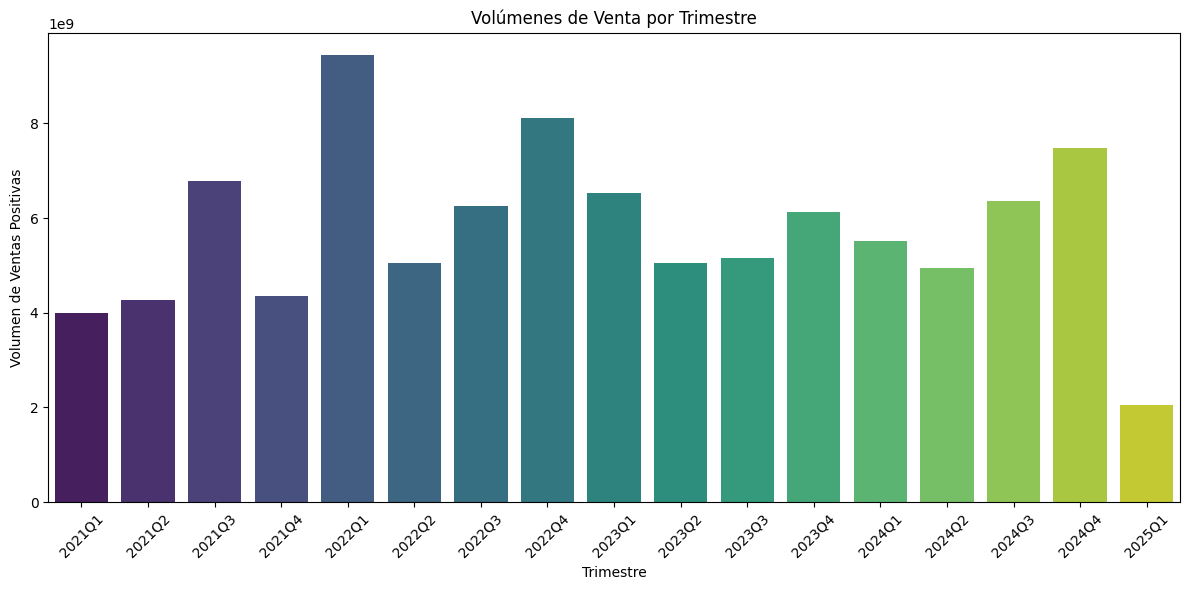

   Trimestre  Vent_positivas
0     2021Q1    4.000458e+09
1     2021Q2    4.264143e+09
2     2021Q3    6.791711e+09
3     2021Q4    4.348372e+09
4     2022Q1    9.441348e+09
5     2022Q2    5.054174e+09
6     2022Q3    6.255122e+09
7     2022Q4    8.122658e+09
8     2023Q1    6.531583e+09
9     2023Q2    5.041615e+09
10    2023Q3    5.164024e+09
11    2023Q4    6.127719e+09
12    2024Q1    5.512443e+09
13    2024Q2    4.939055e+09
14    2024Q3    6.353362e+09
15    2024Q4    7.482250e+09
16    2025Q1    2.048765e+09


In [373]:
# Convertir la columna 'FechaDocumento' a tipo datetime
df['FechaDocumento'] = pd.to_datetime(df['FechaDocumento'])

# Agregar una columna de trimestre
df['Trimestre'] = df['FechaDocumento'].dt.to_period('Q')

# Agrupar los volúmenes de venta por trimestre
ventas_por_trimestre = df.groupby('Trimestre')['Vent_positivas'].sum().reset_index()

# Visualización de los volúmenes de venta por trimestre
plt.figure(figsize=(12, 6))
sns.barplot(data=ventas_por_trimestre, x='Trimestre', y='Vent_positivas', palette='viridis')
plt.title('Volúmenes de Venta por Trimestre')
plt.xlabel('Trimestre')
plt.ylabel('Volumen de Ventas Positivas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Imprimir los resultados
print(ventas_por_trimestre)

C:\Users\jhont\AppData\Local\Temp\ipykernel_30072\910522318.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_por_mes, x='Mes', y='Vent_positivas', palette='viridis')


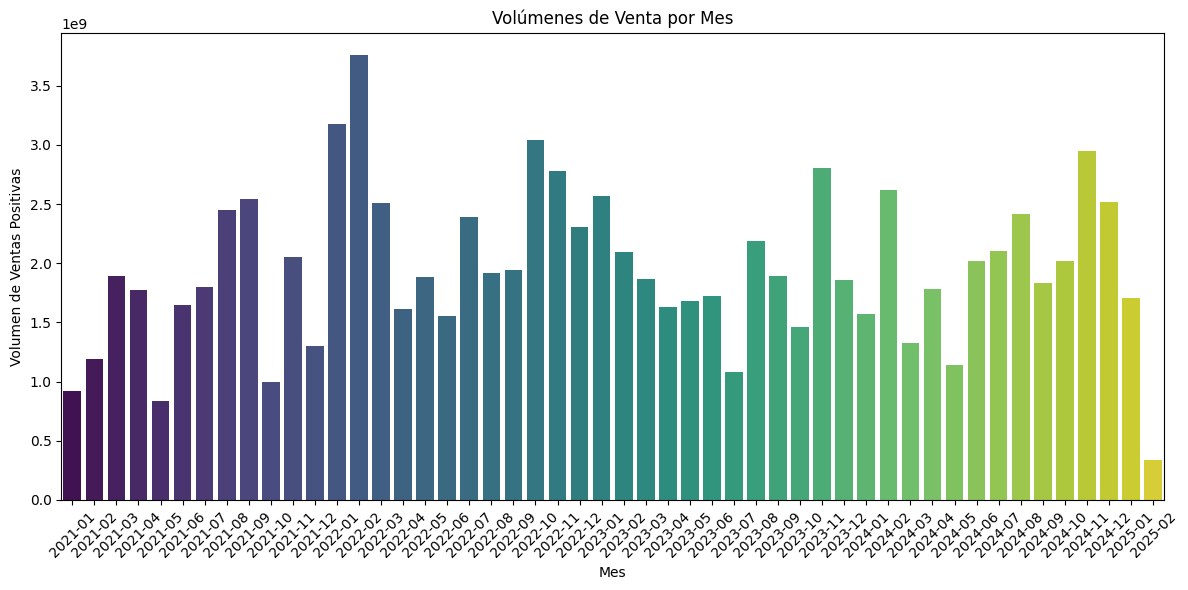

        Mes  Vent_positivas
0   2021-01    9.207800e+08
1   2021-02    1.190113e+09
2   2021-03    1.889565e+09
3   2021-04    1.777616e+09
4   2021-05    8.363872e+08
5   2021-06    1.650139e+09
6   2021-07    1.803444e+09
7   2021-08    2.446851e+09
8   2021-09    2.541416e+09
9   2021-10    9.943404e+08
10  2021-11    2.051899e+09
11  2021-12    1.302133e+09
12  2022-01    3.175675e+09
13  2022-02    3.759795e+09
14  2022-03    2.505878e+09
15  2022-04    1.613154e+09
16  2022-05    1.885065e+09
17  2022-06    1.555955e+09
18  2022-07    2.394091e+09
19  2022-08    1.919280e+09
20  2022-09    1.941752e+09
21  2022-10    3.038743e+09
22  2022-11    2.776562e+09
23  2022-12    2.307353e+09
24  2023-01    2.567480e+09
25  2023-02    2.094347e+09
26  2023-03    1.869755e+09
27  2023-04    1.631704e+09
28  2023-05    1.682167e+09
29  2023-06    1.727744e+09
30  2023-07    1.084916e+09
31  2023-08    2.188999e+09
32  2023-09    1.890109e+09
33  2023-10    1.459444e+09
34  2023-11    2.806

In [346]:
# Convertir la columna 'FechaDocumento' a tipo datetime
df['FechaDocumento'] = pd.to_datetime(df['FechaDocumento'])

# Agregar una columna de mes
df['Mes'] = df['FechaDocumento'].dt.to_period('M')

# Agrupar los volúmenes de venta por mes
ventas_por_mes = df.groupby('Mes')['Vent_positivas'].sum().reset_index()

# Visualización de los volúmenes de venta por mes
plt.figure(figsize=(12, 6))
sns.barplot(data=ventas_por_mes, x='Mes', y='Vent_positivas', palette='viridis')
plt.title('Volúmenes de Venta por Mes')
plt.xlabel('Mes')
plt.ylabel('Volumen de Ventas Positivas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Imprimir los resultados
print(ventas_por_mes)

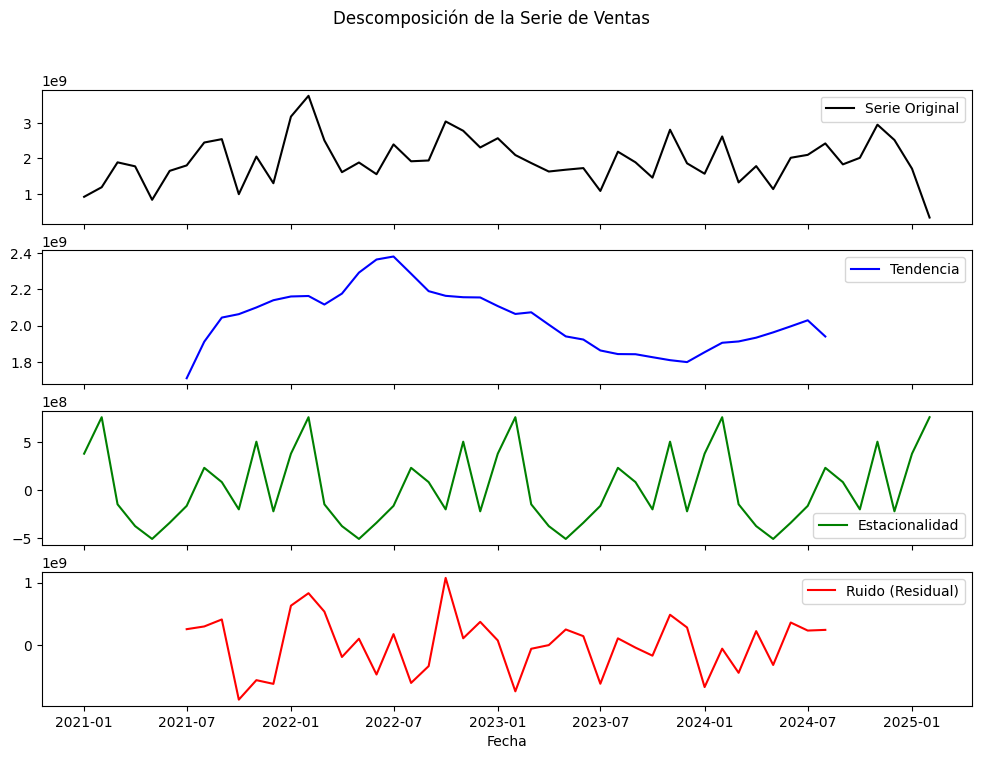

Tendencia:
Mes
2021-07-01    1.711011e+09
2021-08-01    1.912035e+09
2021-09-01    2.044785e+09
2021-10-01    2.063612e+09
2021-11-01    2.100454e+09
2021-12-01    2.140225e+09
2022-01-01    2.160911e+09
2022-02-01    2.163539e+09
2022-03-01    2.116571e+09
2022-04-01    2.176768e+09
2022-05-01    2.292146e+09
2022-06-01    2.364224e+09
2022-07-01    2.380767e+09
2022-08-01    2.286032e+09
2022-09-01    2.190133e+09
2022-10-01    2.164401e+09
2022-11-01    2.156720e+09
2022-12-01    2.155424e+09
2023-01-01    2.108033e+09
2023-02-01    2.064722e+09
2023-03-01    2.073808e+09
2023-04-01    2.005853e+09
2023-05-01    1.941283e+09
2023-06-01    1.923965e+09
2023-07-01    1.863830e+09
2023-08-01    1.844036e+09
2023-09-01    1.843154e+09
2023-10-01    1.826811e+09
2023-11-01    1.810439e+09
2023-12-01    1.799838e+09
2024-01-01    1.854236e+09
2024-02-01    1.906199e+09
2024-03-01    1.913455e+09
2024-04-01    1.934262e+09
2024-05-01    1.963402e+09
2024-06-01    1.996627e+09
2024-07-01   

In [347]:
# Convertir la columna 'FechaDocumento' a tipo datetime
df['FechaDocumento'] = pd.to_datetime(df['FechaDocumento'])

# Agregar una columna de mes
df['Mes'] = df['FechaDocumento'].dt.to_period('M')

# Agrupar los volúmenes de venta por mes
ventas_por_mes = df.groupby('Mes')['Vent_positivas'].sum().reset_index()

# Convertir la columna 'Mes' a tipo datetime para la descomposición estacional
ventas_por_mes['Mes'] = ventas_por_mes['Mes'].dt.to_timestamp()

# Establecer la columna 'Mes' como índice
ventas_por_mes.set_index('Mes', inplace=True)

# Aplicar descomposición estacional (modelo aditivo)
descomposicion = seasonal_decompose(ventas_por_mes['Vent_positivas'], model='additive', period=12)

# Graficar resultados
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

# Serie original
axes[0].plot(ventas_por_mes.index, ventas_por_mes['Vent_positivas'], label="Serie Original", color='black')
axes[0].legend()

# Tendencia
axes[1].plot(ventas_por_mes.index, descomposicion.trend, label="Tendencia", color='blue')
axes[1].legend()

# Estacionalidad
axes[2].plot(ventas_por_mes.index, descomposicion.seasonal, label="Estacionalidad", color='green')
axes[2].legend()

# Residuo
axes[3].plot(ventas_por_mes.index, descomposicion.resid, label="Ruido (Residual)", color='red')
axes[3].legend()

plt.xlabel("Fecha")
plt.suptitle("Descomposición de la Serie de Ventas")
plt.show()

# Imprimir los resultados de la descomposición
print("Tendencia:")
print(descomposicion.trend.dropna())
print("\nEstacionalidad:")
print(descomposicion.seasonal.dropna())
print("\nResiduo:")
print(descomposicion.resid.dropna())

# 📊 Análisis de la Descomposición de la Serie de Ventas

## 🔎 Componentes de la Serie Temporal

### 1️⃣ Serie Original  
- Se observan fluctuaciones irregulares con picos en diferentes momentos.  
- Indica una alta variabilidad en las ventas a lo largo del tiempo.  

### 2️⃣ Tendencia  
- Crecimiento sostenido hasta mediados de 2022.  
- Luego se observa una caída progresiva, estabilizándose a finales de 2023.  
- Posibles causas: cambios en la demanda, impacto económico o estrategias comerciales.  

### 3️⃣ Estacionalidad  
- Se identifican patrones cíclicos cada 12 meses.  
- Sugiere que las ventas tienen una fuerte dependencia de factores estacionales.  
- Puede estar influenciado por temporadas altas y bajas de consumo.  

### 4️⃣ Ruido (Residual)  
- Alta variabilidad en los residuos, lo que indica factores no explicados por la tendencia y la estacionalidad.  
- Puede deberse a eventos imprevistos, cambios en el mercado o factores externos no modelados.  

## 🚀 Conclusiones y Recomendaciones

✅ **Analizar la caída en la tendencia después de 2022**  
   - ¿Hubo cambios en la estrategia de ventas o en la competencia?  
   - ¿Factores macroeconómicos afectaron la demanda?  

✅ **Aprovechar la estacionalidad para optimizar estrategias**  
   - Ajustar campañas de marketing según los ciclos identificados.  
   - Planificar inventarios y recursos en función de los patrones de demanda.  

✅ **Investigar la variabilidad en los residuos**  
   - Identificar posibles eventos atípicos que puedan estar afectando las ventas.  
   - Incorporar variables externas al modelo para mejorar la explicación de la serie.  



In [ ]:
df.columns

In [348]:
# Convertir la columna 'FechaDocumento' a tipo datetime
df['FechaDocumento'] = pd.to_datetime(df['FechaDocumento'])

# Agrupar los volúmenes de venta por mes
ventas_por_mes = df.groupby(df['FechaDocumento'].dt.to_period('M'))['Vent_positivas'].sum().reset_index()
ventas_por_mes['FechaDocumento'] = ventas_por_mes['FechaDocumento'].dt.to_timestamp()

# Renombrar las columnas para Prophet
ventas_por_mes = ventas_por_mes.rename(columns={'FechaDocumento': 'ds', 'Vent_positivas': 'y'})

# Inicializar y entrenar el modelo
modelo = Prophet()
modelo.fit(ventas_por_mes)

# Crear un DataFrame con futuras fechas (12 meses adelante)
futuro = modelo.make_future_dataframe(periods=12, freq='M')

# Hacer la predicción
prediccion = modelo.predict(futuro)



13:45:13 - cmdstanpy - INFO - Chain [1] start processing
13:45:15 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\jhont\OneDrive\Escritorio\prueba_tecnica_Cristian\jt1\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


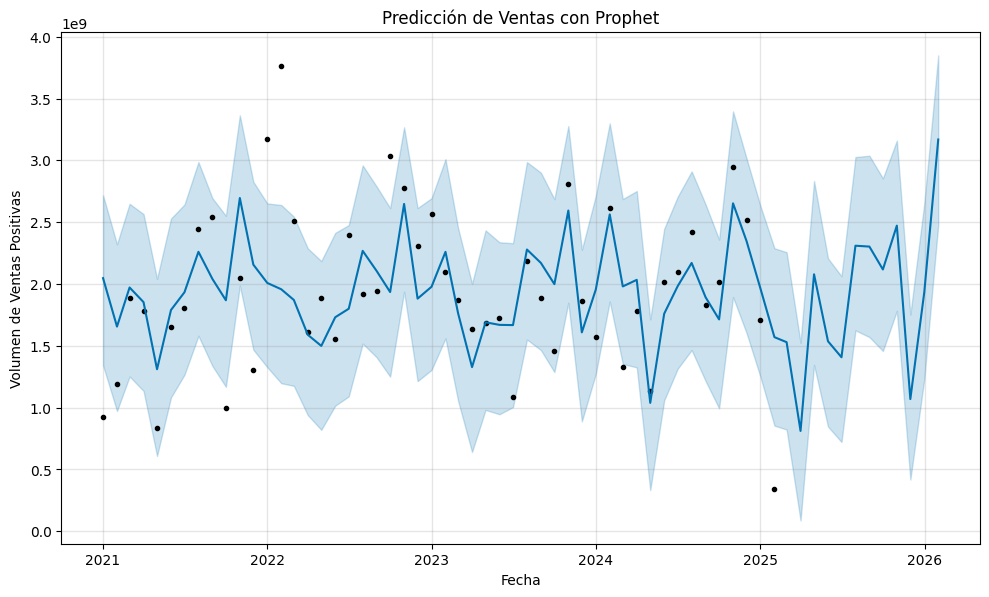

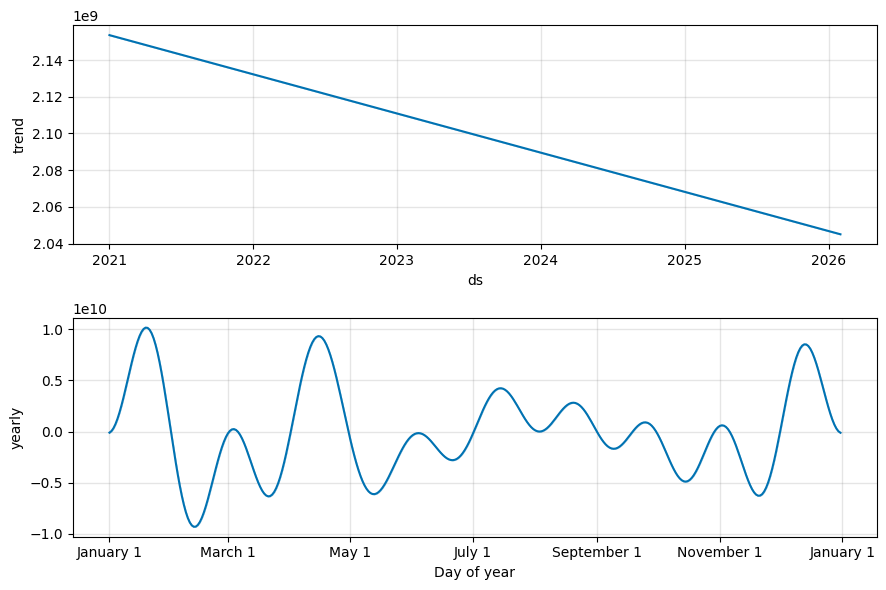

In [349]:
# Graficar la predicción
fig = modelo.plot(prediccion)
plt.title("Predicción de Ventas con Prophet")
plt.xlabel("Fecha")
plt.ylabel("Volumen de Ventas Positivas")
plt.show()

# Graficar los componentes de tendencia y estacionalidad
fig2 = modelo.plot_components(prediccion)
plt.show()

# 📊 Análisis de Predicción de Ventas con Prophet

## 🔎 Observaciones Clave

### 1️⃣ Gráfico Principal: Predicción con Intervalos de Confianza  
- **Línea azul**: Predicción de ventas futuras.  
- **Puntos negros**: Datos reales de ventas.  
- **Zona azul clara**: Intervalo de confianza (incertidumbre en la predicción).  
- Se observa una **alta variabilidad en las predicciones**, lo que indica que la serie de datos tiene una fuerte influencia de factores externos no capturados completamente por el modelo.  
- La tendencia general **muestra estabilidad**, pero con fluctuaciones notables.  

### 2️⃣ Tendencia General (Gráfico Intermedio)  
- **Tendencia en descenso sostenido** hasta 2026.  
- Puede estar indicando una desaceleración en las ventas a largo plazo.  
- Es crucial analizar las causas de esta tendencia:  
  - ¿Cambio en la demanda del mercado?  
  - ¿Factores económicos o competencia?  
  - ¿Estrategias comerciales poco efectivas?  

### 3️⃣ Componente Estacional (Gráfico Inferior)  
- Se observa un **patrón cíclico anual**, con picos y valles en fechas recurrentes.  
- Esto sugiere que las ventas siguen una **estacionalidad fuerte**.  
- Se pueden identificar los períodos de mayor y menor venta para ajustar estrategias comerciales.  

## 🚀 Conclusiones y Recomendaciones

✅ **Investigar la caída en la tendencia**  
   - Profundizar en análisis de mercado para identificar factores que afectan la demanda.  
   - Evaluar cambios en estrategias de precios, marketing o distribución.  

✅ **Aprovechar la estacionalidad**  
   - Planificar campañas de marketing y promociones en períodos de alta demanda.  
   - Ajustar producción e inventarios a los ciclos estacionales.  

✅ **Mejorar la precisión del modelo**  
   - Incluir variables adicionales en Prophet, como indicadores económicos, promociones y eventos externos.  
   - Evaluar modelos complementarios (ARIMA, LSTM) para comparar resultados. 


encontramos la lista de precios referenciados de la lista de ventas con el nombre del producto y el precio de compra 

In [355]:
 #Asegurarse de que las columnas necesarias existen
if 'NombreProducto' in df.columns and 'Cantidad_Total' in df.columns and 'Vent_positivas' in df.columns:
    # Calcular el precio de cada producto
    df['Precio'] = df['Vent_positivas'] / df['Cantidad_Total']
    
    # Agrupar por producto y calcular el precio promedio
    precio_por_producto = df.groupby('NombreProducto')['Precio'].mean().reset_index()
    
    # Imprimir los resultados
    print(precio_por_producto)
else:
    print("Las columnas necesarias no existen en el DataFrame.")

                 NombreProducto         Precio
0               ACIDO ESTEARICO   18946.432016
1       ACIDO ESTEARICO HPS P10   15859.577787
2                         AMINA   86548.117978
3                ANGEL CQP M 13   82720.000000
4                 BAMBU CQP E15     240.000000
..                          ...            ...
132                       VIBAR  126787.661972
133                VIBAR CQPA09   69661.578947
134             VIRGEN CQP M 11  141136.250000
135  VIRGEN DE GUADALUPE CQP 09   99340.000000
136        VIRGEN NIÑA CQP M 16  108777.500000

[137 rows x 2 columns]


In [359]:
df[df['Descuento'] == True].apply(lambda x: (x['PrecioLista'] - x['PrecioReal']) / x['PrecioLista'], axis=1).mean()


np.float64(0.28531180739661294)

hallamos las compras que son hechas bajo algun descuento haciendo la inversa 

In [351]:
# Asegurarse de que las columnas necesarias existen
if 'NombreProducto' in df.columns and 'Cantidad_Total' in df.columns and 'Vent_positivas' in df.columns:
    # Calcular el precio promedio de cada producto
    df['Precio'] = df['Vent_positivas'] / df['Cantidad_Total']
    precio_por_producto = df.groupby('NombreProducto')['Precio'].mean().reset_index()
    precio_por_producto = precio_por_producto.rename(columns={'Precio': 'PrecioLista'})
    
    # Unir el precio de lista con el DataFrame original
    df = pd.merge(df, precio_por_producto, on='NombreProducto', how='left')
    
    # Calcular el precio real de cada transacción
    df['PrecioReal'] = df['Vent_positivas'] / df['Cantidad_Total']
    
    # Identificar las transacciones con descuento
    df['Descuento'] = df['PrecioReal'] < df['PrecioLista']
    
    # Imprimir los resultados
    print(df[['NombreProducto', 'Cantidad_Total', 'Vent_positivas', 'PrecioLista', 'PrecioReal', 'Descuento']])
else:
    print("Las columnas necesarias no existen en el DataFrame.")

              NombreProducto  Cantidad_Total  Vent_positivas    PrecioLista  \
0          POLIOL POLIMERICO            -8.0             0.0   25561.715098   
1                        MDI         -1850.0             0.0   31152.286325   
2             PARAFINA MEDIA          -100.0             0.0   16264.329611   
3           PARAFINA LIVIANA          -600.0             0.0   15068.714382   
4               T.D.I. 80/20           -50.0             0.0   29792.347841   
...                      ...             ...             ...            ...   
19929              PIOLA #15             4.0         58790.0   14048.138298   
19930           VIBAR CQPA09             1.0         70715.0   69661.578947   
19931  PAPEL CELOFAN CRISTAL             1.0       1112710.0  550852.307956   
19932  PAPEL CELOFAN CRISTAL             1.0       1112710.0  550852.307956   
19933  PAPEL CELOFAN CRISTAL             4.0       4201260.0  550852.307956   

       PrecioReal  Descuento  
0            -0.0   

la informacion suministrada resalta el problema con las ecuaciones negativas que es necesario crear un filtro 

In [357]:
# Asegurarse de que las columnas necesarias existen
if 'NombreProducto' in df.columns and 'Cantidad_Total' in df.columns and 'Vent_positivas' in df.columns:
    # Filtrar filas con valores negativos en 'Cantidad_Total'
    df = df[df['Cantidad_Total'] > 0]
    
    
    # Calcular el precio promedio de cada producto
    df['Precio'] = df['Vent_positivas'] / df['Cantidad_Total']
    precio_por_producto = df.groupby('NombreProducto')['Precio'].mean().reset_index()
    precio_por_producto = precio_por_producto.rename(columns={'Precio': 'PrecioLista'})
    
    # Verificar el DataFrame de precios por producto
    print("Precios por producto:")
    print(precio_por_producto.head())
    
    # Unir el precio de lista con el DataFrame original
    df = pd.merge(df, precio_por_producto, on='NombreProducto', how='left')
    
    # Verificar el DataFrame después de la unión
    print("DataFrame después de la unión:")
    print(df.head())
    
    # Calcular el precio real de cada transacción
    df['PrecioReal'] = df['Vent_positivas'] / df['Cantidad_Total']
    
    # Identificar las transacciones con descuento
    df['Descuento'] = df['PrecioReal'] < df['PrecioLista']
    
    # Imprimir los resultados
    print(df[['NombreProducto', 'Cantidad_Total', 'Vent_positivas', 'PrecioLista', 'PrecioReal', 'Descuento']])
else:
    print("Las columnas necesarias no existen en el DataFrame.")

Precios por producto:
            NombreProducto   PrecioLista
0          ACIDO ESTEARICO  18946.432016
1  ACIDO ESTEARICO HPS P10  15859.577787
2                    AMINA  86548.117978
3           ANGEL CQP M 13  82720.000000
4            BAMBU CQP E15    240.000000
DataFrame después de la unión:
   Cantidad_Total  Venta_Total NumeroDocumento NombreCliente  \
0           100.0    3393250.0       FE0000552   Cliente 192   
1           100.0    3482250.0       FE0000553   Cliente 192   
2           168.0    5197500.0       FE0000553   Cliente 192   
3            50.0    1870500.0       FE0000554   Cliente 192   
4            42.0     937650.0       FE0000554   Cliente 192   

           Municipio        Departamento   NombreProducto    NitCliente  \
0  VILLA DEL ROSARIO  NORTE DE SANTANDER     T.D.I. 80/20  7584009777-8   
1  VILLA DEL ROSARIO  NORTE DE SANTANDER     T.D.I. 80/20  7584009777-8   
2  VILLA DEL ROSARIO  NORTE DE SANTANDER  POLIOL ESTANDAR  7584009777-8   
3  VILLA DEL ROS

In [358]:
df['Descuento'].value_counts()

Descuento
True     11830
False     7358
Name: count, dtype: int64

In [360]:
df.head()

,Cantidad_Total,Venta_Total,NumeroDocumento,NombreCliente,Municipio,Departamento,NombreProducto,NitCliente,Fuente,CodVendedor,...,Dev_positivas,meses_desde_documento,Trimestre,Mes,Precio,PrecioLista_x,PrecioReal,Descuento,PrecioLista_y,PrecioLista
0,100.0,3393250.0,FE0000552,Cliente 192,VILLA DEL ROSARIO,NORTE DE SANTANDER,T.D.I. 80/20,7584009777-8,ventas,8,...,0.0,35,2022Q2,2022-04,33932.5,29792.347841,33932.5,False,30930.630051,30930.630051
1,100.0,3482250.0,FE0000553,Cliente 192,VILLA DEL ROSARIO,NORTE DE SANTANDER,T.D.I. 80/20,7584009777-8,ventas,8,...,0.0,35,2022Q2,2022-04,34822.5,29792.347841,34822.5,False,30930.630051,30930.630051
2,168.0,5197500.0,FE0000553,Cliente 192,VILLA DEL ROSARIO,NORTE DE SANTANDER,POLIOL ESTANDAR,7584009777-8,ventas,8,...,0.0,35,2022Q2,2022-04,30937.5,23604.581987,30937.5,False,24577.352817,24577.352817
3,50.0,1870500.0,FE0000554,Cliente 192,VILLA DEL ROSARIO,NORTE DE SANTANDER,T.D.I. 80/20,7584009777-8,ventas,8,...,0.0,23,2023Q2,2023-04,37410.0,29792.347841,37410.0,False,30930.630051,30930.630051
4,42.0,937650.0,FE0000554,Cliente 192,VILLA DEL ROSARIO,NORTE DE SANTANDER,POLIOL ESTANDAR,7584009777-8,ventas,8,...,0.0,23,2023Q2,2023-04,22325.0,23604.581987,22325.0,True,24577.352817,24577.352817


In [ ]:
# Asegurarse de que las columnas necesarias existen
if 'NombreProducto' in df.columns and 'Cantidad_Total' in df.columns and 'Vent_positivas' in df.columns:
    # Filtrar filas con valores negativos en 'Cantidad_Total'
    df = df[df['Cantidad_Total'] > 0]
    
    # Calcular el precio promedio de cada producto
    df['Precio'] = df['Vent_positivas'] / df['Cantidad_Total']
    precio_por_producto = df.groupby('NombreProducto')['Precio'].mean().reset_index()
    precio_por_producto = precio_por_producto.rename(columns={'Precio': 'PrecioLista'})
    
    # Unir el precio de lista con el DataFrame original, especificando sufijos para columnas duplicadas
    df = pd.merge(df, precio_por_producto, on='NombreProducto', how='left', suffixes=('', '_Lista'))
    
    # Calcular el precio real de cada transacción
    df['PrecioReal'] = df['Vent_positivas'] / df['Cantidad_Total']
    
    # Identificar las transacciones con descuento
    df['Descuento'] = df['PrecioReal'] < df['PrecioLista']
    
    # Filtrar las transacciones con descuento
    df_descuento = df[df['Descuento']]
    
    # Agregar una columna de fecha sin hora
    df_descuento['Fecha'] = df_descuento['FechaDocumento'].dt.date
    df['Fecha'] = df['FechaDocumento'].dt.date
    
    # Agrupar por fecha y calcular el porcentaje de descuentos por día
    descuentos_por_dia = df_descuento.groupby('Fecha').size().reset_index(name='Descuentos')
    total_transacciones_por_dia = df.groupby('Fecha').size().reset_index(name='TotalTransacciones')
    descuentos_por_dia = pd.merge(descuentos_por_dia, total_transacciones_por_dia, on='Fecha')
    descuentos_por_dia['PorcentajeDescuento'] = (descuentos_por_dia['Descuentos'] / descuentos_por_dia['TotalTransacciones']) * 100
    
else:
    print("Las columnas necesarias no existen en el DataFrame.")

C:\Users\jhont\AppData\Local\Temp\ipykernel_30072\3795767102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=descuentos_por_dia, x='Fecha', y='PorcentajeDescuento', palette='viridis')


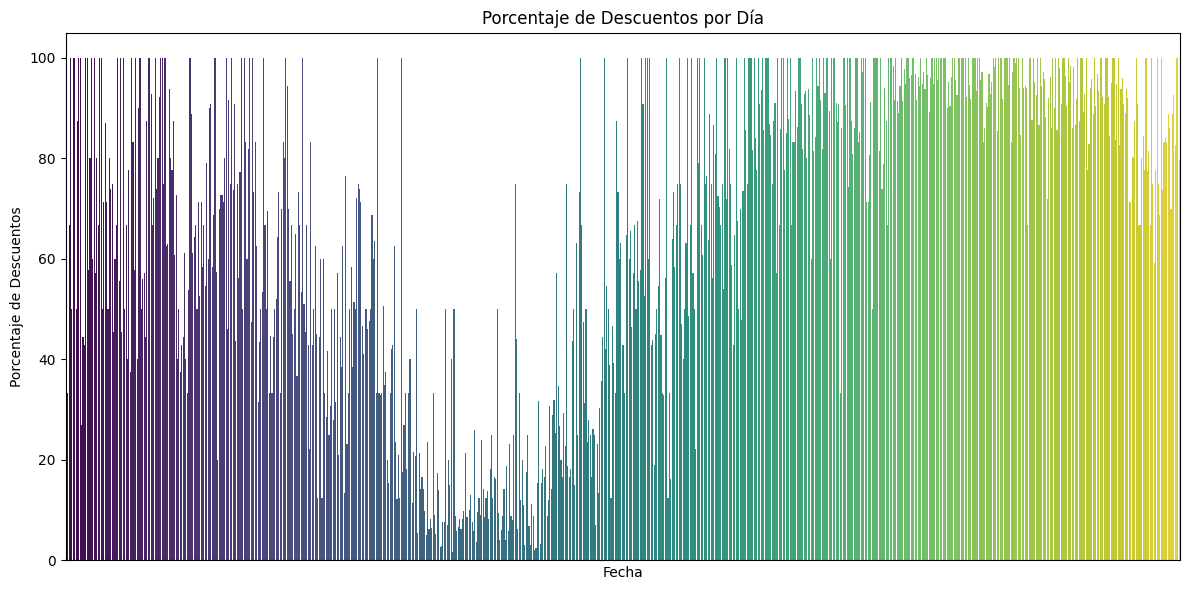

In [181]:
 # Visualización de los días de descuentos y su porcentaje
plt.figure(figsize=(12, 6))
sns.barplot(data=descuentos_por_dia, x='Fecha', y='PorcentajeDescuento', palette='viridis')
plt.title('Porcentaje de Descuentos por Día')
plt.xlabel('Fecha')
plt.ylabel('Porcentaje de Descuentos')
plt.xticks([], [])
plt.tight_layout()
plt.show()

In [ ]:
# Asegurarse de que las columnas necesarias existen
if 'NombreProducto' in df.columns and 'Cantidad_Total' in df.columns and 'Vent_positivas' in df.columns:
    # Filtrar filas con valores negativos en 'Cantidad_Total'
    df = df[df['Cantidad_Total'] > 0]
    
    # Calcular el precio promedio de cada producto
    df['Precio'] = df['Vent_positivas'] / df['Cantidad_Total']
    precio_por_producto = df.groupby('NombreProducto')['Precio'].mean().reset_index()
    precio_por_producto = precio_por_producto.rename(columns={'Precio': 'PrecioLista'})
    
    # Unir el precio de lista con el DataFrame original, especificando sufijos para columnas duplicadas
    df = pd.merge(df, precio_por_producto, on='NombreProducto', how='left', suffixes=('', '_Lista'))
    
    # Calcular el precio real de cada transacción
    df['PrecioReal'] = df['Vent_positivas'] / df['Cantidad_Total']
    
    # Identificar las transacciones con descuento
    df['Descuento'] = df['PrecioReal'] < df['PrecioLista']
    
    # Filtrar las transacciones con descuento
    df_descuento = df[df['Descuento']]
    
    # Agregar una columna de fecha sin hora
    df_descuento['Fecha'] = df_descuento['FechaDocumento'].dt.date
    df['Fecha'] = df['FechaDocumento'].dt.date
    
    # Agrupar por fecha y calcular el porcentaje de descuentos por día
    descuentos_por_dia = df_descuento.groupby('Fecha').size().reset_index(name='Descuentos')
    total_transacciones_por_dia = df.groupby('Fecha').size().reset_index(name='TotalTransacciones')
    descuentos_por_dia = pd.merge(descuentos_por_dia, total_transacciones_por_dia, on='Fecha')
    descuentos_por_dia['PorcentajeDescuento'] = (descuentos_por_dia['Descuentos'] / descuentos_por_dia['TotalTransacciones']) * 100
      # Identificar los días con mayor porcentaje de descuento (por ejemplo, los días con porcentaje de descuento mayor al 50%)
    dias_mayor_descuento = descuentos_por_dia[descuentos_por_dia['PorcentajeDescuento'] > 50]['Fecha']
    
    # Filtrar las transacciones en esos días
    transacciones_mayor_descuento = df[df['Fecha'].isin(dias_mayor_descuento)]
    
    # Calcular la frecuencia de los clientes en esos días
    frecuencia_clientes = transacciones_mayor_descuento['NombreCliente'].value_counts().reset_index()
    frecuencia_clientes.columns = ['NombreCliente', 'Frecuencia']
else:
    print("Las columnas necesarias no existen en el DataFrame.")   
    

C:\Users\jhont\AppData\Local\Temp\ipykernel_30072\461045163.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_descuento['Fecha'] = df_descuento['FechaDocumento'].dt.date


C:\Users\jhont\AppData\Local\Temp\ipykernel_30072\469135671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=frecuencia_clientes, x='NombreCliente', y='Frecuencia', palette='viridis')


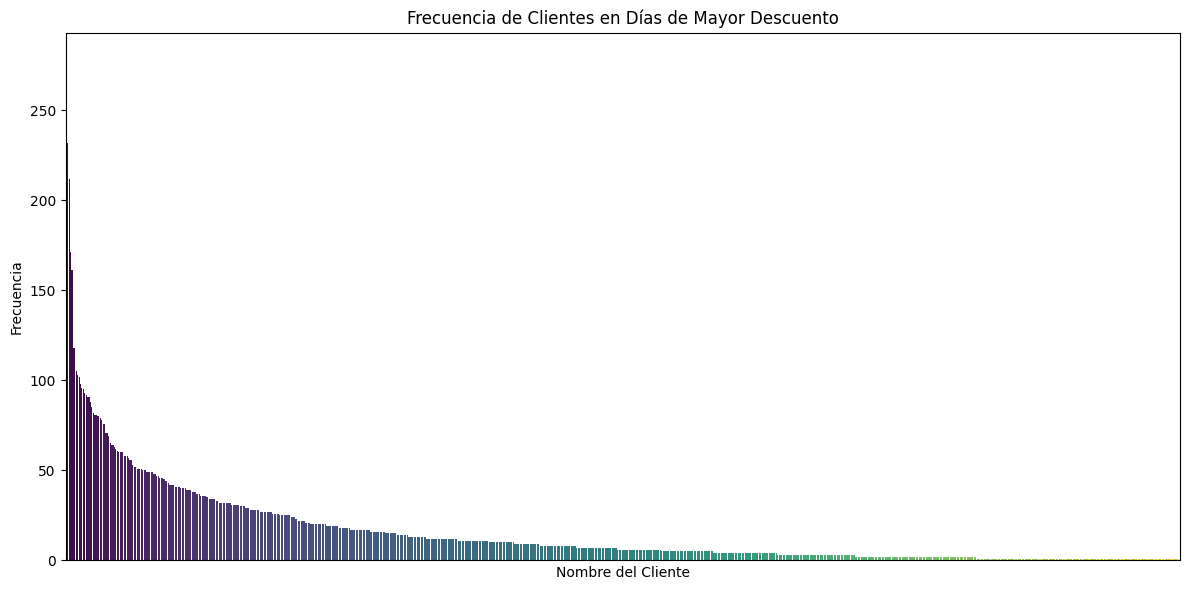

In [185]:
    # Visualización de la frecuencia de los clientes en días de mayor descuento
plt.figure(figsize=(12, 6))
sns.barplot(data=frecuencia_clientes, x='NombreCliente', y='Frecuencia', palette='viridis')
plt.title('Frecuencia de Clientes en Días de Mayor Descuento')
plt.xlabel('Nombre del Cliente')
plt.ylabel('Frecuencia')
plt.xticks([], [])
plt.tight_layout()
plt.show()   

top 5O 

Análisis de la Gráfica
1. Tendencia de la Frecuencia de Clientes
La distribución muestra una cola larga a la derecha, lo que indica que unos pocos clientes compran con mucha frecuencia en días de descuento, mientras que la mayoría lo hace solo unas pocas veces.
Esto es un comportamiento de Ley de Potencia o distribución Zipf, común en ventas, donde pocos clientes generan la mayoría de las transacciones.
2. Clientes con Mayor Frecuencia
El primer grupo de clientes tiene más de 100 compras, con algunos llegando a más de 250 transacciones en días de descuento.
Después de los primeros 50 clientes, la frecuencia cae drásticamente.
3. Posibles Interpretaciones
Clientes recurrentes: Algunos clientes parecen aprovechar muy bien los días de descuento, lo que puede indicar clientes fieles que buscan ahorro.
Mayoría ocasional: La mayoría de los clientes compra poco en estos días, lo que sugiere que los descuentos no atraen tanto a ciertos perfiles.
¿Reventa o compras personales?: Si los clientes más frecuentes son negocios o revendedores, podrías analizar si los descuentos están beneficiando a clientes finales o mayoristas.

